In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error
import numpy as np


# حذف ستون خالی و ستون‌های تاریخ
df = df.drop(columns=[ 'Delivery date', 'Date of issue', 'Bill of lading registration time'])

y = df['Total fare']

numerical_features = [
    'weight', 'distance', 'Scale fee', 'Evacuation fee', 'added value',
    'Insurance amount', 'Loading fee', 'rent'
]

categorical_features = [
    'product name', 'The name of the destination city', 'Name of the city of orgin', 'Company name'
]

X = df[numerical_features + categorical_features]

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features),
        ('num', 'passthrough', numerical_features)
    ]
)

model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print(f'RMSE on test set: {rmse:.2f}')


RMSE on test set: 6174429.47


In [ ]:
r2 = model.score(X_test, y_test)
print(f'R^2 on test set: {r2:.4f}')

R^2 on test set: 0.9921


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# فرض کنیم y هدفمون 'Value added insurance premium' هست
target = 'Value added insurance premium'

# انتخاب فقط ستون‌های عددی
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

# محاسبه ماتریس همبستگی
corr = df[numeric_cols].corr()

# همبستگی متغیر هدف با بقیه ویژگی‌ها
target_corr = corr[target].sort_values(ascending=False)

print(target_corr)

Value added insurance premium    1.000000
Insurance amount                 0.960940
Total fare                       0.124005
Complications of moving goods    0.087193
rent                             0.087183
Calculation fare                 0.087150
Company commission               0.085868
Loader code                      0.075202
Sender is national ID            0.073526
Recipient is national ID         0.056926
Postal code of the sender        0.049160
distance                         0.042183
Received from the driver         0.041590
Scale fee                        0.033898
Postal code of recipient         0.029044
Loading fee                      0.028690
Packaging code                   0.020134
Serial code                      0.020070
weight                           0.018787
Company Code                     0.007337
Evacuation fee                   0.007139
Device smart card                0.003905
product code                     0.002673
Bill of lading number            0

In [ ]:
import scipy.stats as stats

categorical_features = ['product name', 'The name of the destination city', 'Name of the city of orgin', 'Company name']
target = 'Value added insurance premium'

for cat in categorical_features:
    groups = []
    for level in df[cat].unique():
        group = df[df[cat] == level][target]
        groups.append(group)
    f_val, p_val = stats.f_oneway(*groups)
    print(f'ANOVA for {cat}: F={f_val:.2f}, p={p_val:.4f}')


ANOVA for product name: F=35.14, p=0.0000
ANOVA for The name of the destination city: F=12.10, p=0.0000
ANOVA for Name of the city of orgin: F=116.90, p=0.0000
ANOVA for Company name: F=33.41, p=0.0000


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error
import numpy as np

y = df['Value added insurance premium']

numerical_features = [
    'weight', 'distance', 'Scale fee', 'Evacuation fee', 'added value',
    'Insurance amount', 'Loading fee', 'rent'
]

categorical_features = [
    'product name', 'The name of the destination city', 'Name of the city of orgin', 'Company name'
]

X = df[numerical_features + categorical_features]

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features),
        ('num', 'passthrough', numerical_features)
    ]
)

model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print(f'RMSE on test set: {rmse:.2f}')


RMSE on test set: 53262.02


In [ ]:
r2 = model.score(X_test, y_test)
print(f'R^2 on test set: {r2:.4f}')

R^2 on test set: 0.9421


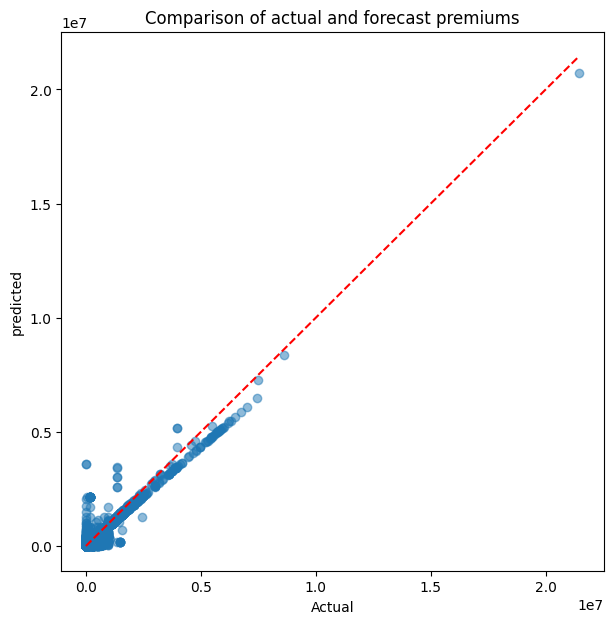

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,10))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')  # خط ایده‌آل
plt.xlabel('Actual')
plt.ylabel('predicted')
plt.title('Comparison of actual and forecast premiums')
plt.show()

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error
import numpy as np

y = df['Company commission']

numerical_features = [
    'weight', 'distance', 'Scale fee', 'Evacuation fee', 'added value',
    'Insurance amount', 'Loading fee', 'rent'
]

categorical_features = [
    'product name', 'The name of the destination city', 'Name of the city of orgin', 'Company name'
]

X = df[numerical_features + categorical_features]

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features),
        ('num', 'passthrough', numerical_features)
    ]
)

model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print(f'RMSE on test set: {rmse:.2f}')

RMSE on test set: 3381929.66


In [ ]:
r2 = model.score(X_test, y_test)
print(f'R^2 on test set: {r2:.4f}')

R^2 on test set: 0.5669


In [ ]:
API_KEY = "b3bc56031f5a49f6825255578c282032"

# یافتن مختصات شهر های ایران

In [ ]:
!pip install pqdm

In [ ]:
from tqdm import tqdm  # اضافه کردن tqdm

import pandas as pd
import numpy as np
from geopy.geocoders import OpenCage
from geopy.extra.rate_limiter import RateLimiter

df = df.rename(columns={
    "Name of the city of orgin": "origin",
    "The name of the destination city": "destination"
})

cities = pd.Index(df["origin"].tolist() + df["destination"].tolist()).unique()

API_KEY = "b3bc56031f5a49f6825255578c282032"
geolocator = OpenCage(api_key=API_KEY, timeout=10)
geocode = RateLimiter(geolocator.geocode, min_delay_seconds=1)

geoloc_file = "Iran_City_Coords.csv"
try:
    cache = pd.read_csv(geoloc_file, index_col=0)
except FileNotFoundError:
    cache = pd.DataFrame(columns=["lat", "lon"], index=pd.Index([], name="city"))
    cache["lat"] = cache["lat"].astype(float)
    cache["lon"] = cache["lon"].astype(float)

# اینجا حلقه اصلی رو با tqdm می‌پیچیم
for city in tqdm(cities, desc="در حال گرفتن مختصات"):
    if city in cache.index:
        continue
    loc = geocode(f"{city}, Iran")
    if loc:
        cache.loc[city] = [loc.latitude, loc.longitude]
    else:
        cache.loc[city] = [np.nan, np.nan]

cache.to_csv(geoloc_file)
print("مختصات ذخیره شد در Iran_City_Coords.csv")

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
file_path1 = '/content/drive/My Drive/Zahra/Iran_City_Coords.csv'
coords_df = pd.read_csv(file_path1)
coords_df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,city,lat,lon
0,آق قلا,37.013484,54.457666
1,اسالم,37.720567,48.958390
2,بمپور,27.194178,60.455482
3,پرندك مركزي,35.361710,50.679610
4,چوپانان,33.617061,54.377707


In [ ]:
!pip install pandas folium tqdm

In [ ]:
df = df.rename(columns={
    "Name of the city of orgin": "origin",
    "The name of the destination city": "destination"
})
# گروه‌بندی مسیرها و شمارش تعداد تردد
routes = df.groupby(["origin", "destination"]).size().reset_index(name="count")

# اضافه کردن میانگین فاصله مسیرها (میانگین distance برای هر مسیر)
avg_distance = df.groupby(["origin", "destination"])["distance"].mean().reset_index()

# ادغام تعداد و فاصله
routes = routes.merge(avg_distance, on=["origin", "destination"])

# مرتب‌سازی پرترددترین مسیرها
routes = routes.sort_values(by="count", ascending=False)
routes.head()


,origin,destination,count,distance
1105,قم,تهران,59765,148.0
1054,قم,بندرعباس,34947,1136.0
2223,نيزار,قم,31990,51.0
1512,قم,قم,23698,30.0
1752,قم,يزد,17222,482.0


In [ ]:
# اتصال مختصات مبدأ
routes = routes.merge(coords_df, left_on="origin", right_on="city", how="left")
routes = routes.rename(columns={"lat": "origin_lat", "lon": "origin_lon"}).drop(columns=["city"])

# اتصال مختصات مقصد
routes = routes.merge(coords_df, left_on="destination", right_on="city", how="left")
routes = routes.rename(columns={"lat": "dest_lat", "lon": "dest_lon"}).drop(columns=["city"])

routes = routes.dropna(subset=["origin_lat", "origin_lon", "dest_lat", "dest_lon"])

routes.head()


,origin,destination,count,distance,origin_lat,origin_lon,dest_lat,dest_lon
0,قم,تهران,59765,148.0,34.642294,50.880118,35.689252,51.389600
1,قم,بندرعباس,34947,1136.0,34.642294,50.880118,27.179347,56.278142
2,نيزار,قم,31990,51.0,34.307907,50.538684,34.642294,50.880118
3,قم,قم,23698,30.0,34.642294,50.880118,34.642294,50.880118
4,قم,يزد,17222,482.0,34.642294,50.880118,32.040616,54.665719


In [ ]:
import folium

map_center = [routes[["origin_lat", "dest_lat"]].stack().mean(), routes[["origin_lon", "dest_lon"]].stack().mean()]
m = folium.Map(location=map_center, zoom_start=6)

# تعداد مسیرهای پرتردد
top_n = 50
top_routes = routes.head(top_n)

# رسم خطوط مسیرها با ضخامت متناسب با تعداد تردد
min_count = top_routes["count"].min()
max_count = top_routes["count"].max()
range_count = max_count - min_count if max_count != min_count else 1

for _, row in top_routes.iterrows():
    weight = 2 + (row["count"] - min_count) / range_count * 8  # ضخامت بین 2 تا 10
    folium.PolyLine(
        locations=[(row["origin_lat"], row["origin_lon"]), (row["dest_lat"], row["dest_lon"])],
        weight=weight,
        color="blue",
        opacity=0.6,
        tooltip=f"{row['destination']} → {row['origin']} ({row['count']} بار)"
    ).add_to(m)

m.save("frequent_routes_map.html")
print("نقشه ذخیره شد: frequent_routes_map.html")

نقشه ذخیره شد: frequent_routes_map.html


In [ ]:
from google.colab import files
files.download('frequent_routes_map.html')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import pandas as pd

routes_sorted = routes.sort_values(by="count", ascending=False)

# انتخاب ستون‌های مهم برای جدول
table = routes_sorted[["origin", "destination", "count"]]


table.head(10)

,origin,destination,count
0,قم,تهران,59765
1,قم,بندرعباس,34947
2,نيزار,قم,31990
3,قم,قم,23698
4,قم,يزد,17222
5,قم,اصفهان,15755
6,قم,مشهد (خراسان),13202
7,قم,كاشان,11474
8,قم,تبريز,10472
9,قم,شيراز (فارس),8569


In [ ]:
# فیلتر رکوردهای مسیر مبدا: سلفچگان، مقصد: قم
filtered = df[(df["origin"] == "قم") & (df["destination"] == "سلفچگان")]

# تعداد رکوردها
count = filtered.shape[0]
print(f"تعداد مسیرهای سلفچگان به قم: {count}")

تعداد مسیرهای سلفچگان به قم: 2634


In [ ]:
#HeatMap Diagram
from folium.plugins import HeatMap
import folium

# محاسبه تعداد بار برای هر مبدا
origin_counts = df.groupby("origin").size().reset_index(name="count")

# مرج با مختصات شهرها
origin_counts = origin_counts.merge(coords_df, left_on="origin", right_on="city", how="left")

# حذف ردیف‌هایی که مختصات ندارند
origin_counts = origin_counts.dropna(subset=['lat', 'lon'])

# آماده کردن داده برای هیت‌مپ
heat_data = [[row['lat'], row['lon'], row['count']] for idx, row in origin_counts.iterrows()]

# ساخت نقشه
m = folium.Map(location=[35, 51], zoom_start=6)
HeatMap(heat_data).add_to(m)

# ذخیره نقشه
m.save("origin_heatmap.html")

# بررسی پر کاربردترین مبادی و مقاصد

In [ ]:
origin_counts = df.groupby("origin").size().reset_index(name="count")
origin_counts = origin_counts.sort_values(by="count", ascending=False)

origin_counts.head(20)

,origin,count
19,قم,461405
30,نيزار,72032
12,سلفچگان,26848
5,جعفريه (قم),20432
1,انبار نفت قم,11247
26,منطقه ويژه اقتصادي سلفچگان,6556
4,جعفرآباد قم,1235
14,شكوهيه,620
29,نوفل لوشاتو,546
21,قنوات,81


In [ ]:
destination_counts = df.groupby("destination").size().reset_index(name="count")
destination_counts = destination_counts.sort_values(by="count", ascending=False)

destination_counts.head(20)

,destination,count
226,تهران,72121
651,قم,61124
175,بندرعباس,39927
905,يزد,17890
69,اصفهان,16877
38,اراك,16006
664,كاشان,14786
776,مشهد (خراسان),13637
454,ساوه,12154
212,تبريز,11607


In [ ]:
import pandas as pd

# گروه‌بندی بر اساس مبدا و مقصد
cost_distance = df.groupby(["origin", "destination"]).agg({
    "Total fare": "sum",
    "distance": "sum"
}).reset_index()

# محاسبه هزینه به ازای هر کیلومتر
cost_distance["cost_per_km"] = cost_distance["Total fare"] / cost_distance["distance"]

# مرتب‌سازی مسیرها بر اساس هزینه به ازای هر کیلومتر (کاهش یا افزایش)
cost_distance_sorted = cost_distance.sort_values(by="cost_per_km", ascending=False)

# نمایش 20 مسیر با بیشترین هزینه به ازای هر کیلومتر
cost_distance_sorted.head(20)

,origin,destination,Total fare,distance,cost_per_km
2066,نعلبندان (قم),تهران,860000000,178,4.831461e+06
409,جعفريه (قم),گازران قم,35000000,8,4.375000e+06
1849,قم,گمرك قم,130650010,30,4.355000e+06
2071,نعلبندان (قم),كهريزك,220250000,73,3.017123e+06
1646,قم,منطقه مركزي تهران بزرگ,1339246500,444,3.016321e+06
2070,نعلبندان (قم),قم,195000000,69,2.826087e+06
618,سلفچگان,سلفچگان,67308869193,28860,2.332255e+06
1651,قم,منطقه ويژه اقتصادي سلفچگان,991720000,440,2.253909e+06
631,سلفچگان,شكوهيه,880195610,405,2.173322e+06
447,راهجرود,سلفچگان,95000000,45,2.111111e+06


## محاسبه فاصله واقعی جغرافیایی و تحلیل هزینه به ازای هر کیلومتر بر اساس مسافت

In [ ]:
import pandas as pd
from geopy.distance import distance

# مرج مختصات مبدأ
df = df.merge(
    coords_df,
    left_on="origin",
    right_on="city",
    how="left"
).rename(columns={"lat": "origin_lat", "lon": "origin_lon"}).drop(columns=["city"])

# مرج مختصات مقصد
df = df.merge(
    coords_df,
    left_on="destination",
    right_on="city",
    how="left"
).rename(columns={"lat": "dest_lat", "lon": "dest_lon"}).drop(columns=["city"])


In [ ]:
def geo_distance(row):
    if pd.isna(row['origin_lat']) or pd.isna(row['origin_lon']) or pd.isna(row['dest_lat']) or pd.isna(row['dest_lon']):
        return None
    return distance(
        (row['origin_lat'], row['origin_lon']),
        (row['dest_lat'], row['dest_lon'])
    ).km

df['geo_distance_km'] = df.apply(geo_distance, axis=1)


In [ ]:
df = df[df['geo_distance_km'].notnull() & (df['geo_distance_km'] > 0)]

In [ ]:
df['cost_per_km'] = df['Total fare'] / df['geo_distance_km']

In [ ]:
result = df.groupby(
    ['origin', 'destination']
).agg(
    total_fare=('Total fare', 'sum'),
    total_distance=('geo_distance_km', 'sum'),
    avg_cost_per_km=('cost_per_km', 'mean'),
    cost_per_km = ('cost_per_km', list),
    trips=('geo_distance_km', 'count')
).reset_index()

top20 = result.sort_values(by='avg_cost_per_km', ascending=False).head(20)
top20

,origin,destination,total_fare,total_distance,avg_cost_per_km,cost_per_km,trips
1975,نوفل لوشاتو,حسن آباد (تهران),54413000,2.464344,2.208012e+07,"[22080118.659993444, 22080118.659993444]",2
1874,منطقه ويژه اقتصادي سلفچگان,سلفچگان,100000000,5.625461,1.777632e+07,"[17776319.715636063, 17776319.715636063]",2
1748,قم,گمرك قم,130650010,8.151398,1.602793e+07,[16027927.045107659],1
1974,نوفل لوشاتو,تهران,344509500,22.842609,1.508188e+07,"[14675994.122174991, 14184018.803311966, 14446...",12
399,جعفريه (قم),گازران قم,35000000,4.607364,7.596534e+06,[7596534.499424975],1
701,سلفچگان,منطقه ويژه اقتصادي سلفچگان,62784000,8.438192,7.440456e+06,"[7440456.380176631, 7440456.380176631, 7440456...",3
650,سلفچگان,قلعه چم,61526900,16.929248,3.634355e+06,[3634355.26590673],1
1576,قم,منطقه مركزي تهران بزرگ,1339246500,373.810632,3.582687e+06,"[8484509.881109362, 1517183.9739303265, 746367...",3
2108,نيزار,قلعه چم,70000000,21.076826,3.321183e+06,"[3321183.1782562053, 3321183.1782562053]",2
1795,كهك قم,طايقان,67000000,25.567116,2.620554e+06,[2620553.6322509954],1


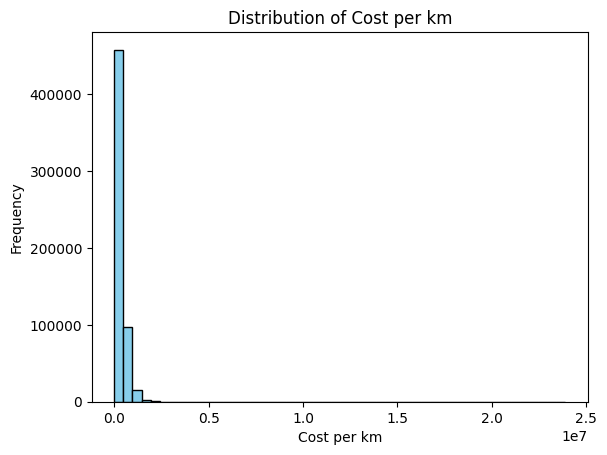

In [ ]:
import matplotlib.pyplot as plt

plt.hist(df['cost_per_km'], bins=50, color='skyblue', edgecolor='black')
plt.xlabel('Cost per km')
plt.ylabel('Frequency')
plt.title('Distribution of Cost per km')
plt.show()

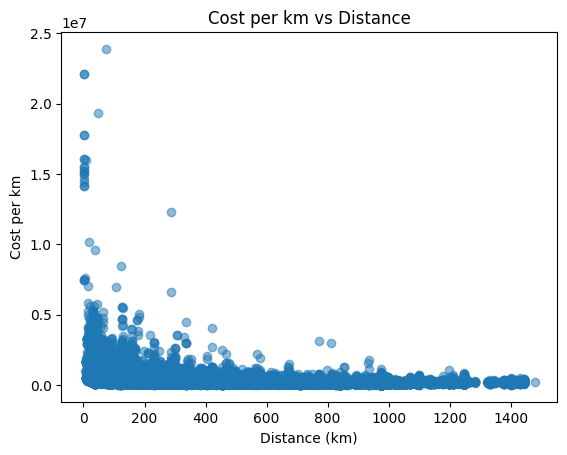

In [ ]:
plt.scatter(df['geo_distance_km'], df['cost_per_km'], alpha=0.5)
plt.xlabel('Distance (km)')
plt.ylabel('Cost per km')
plt.title('Cost per km vs Distance')
plt.show()

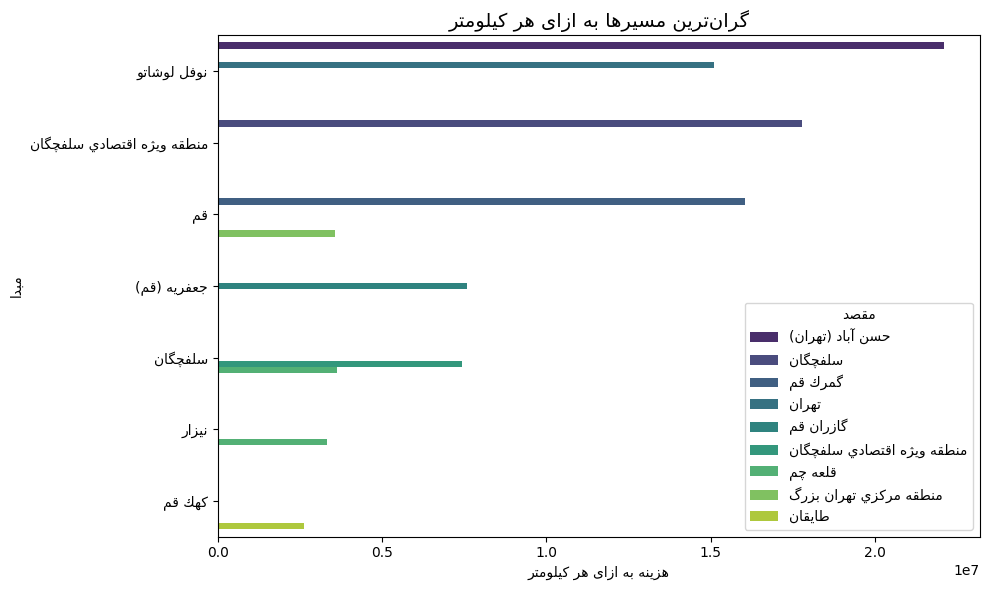

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import arabic_reshaper
from bidi.algorithm import get_display
from matplotlib import rcParams

# تنظیم فونت فارسی
rcParams['font.family'] = 'DejaVu Sans'

# تابع اصلاح متن فارسی
def fix_farsi(text):
    return get_display(arabic_reshaper.reshape(str(text)))

# اصلاح نام شهرها
top_routes['origin'] = top_routes['origin'].apply(fix_farsi)
top_routes['destination'] = top_routes['destination'].apply(fix_farsi)

# رسم نمودار
plt.figure(figsize=(10, 6))
sns.barplot(
    data=top_routes,
    x='avg_cost_per_km',
    y='origin',
    hue='destination',
    palette='viridis'
)

plt.xlabel(fix_farsi("هزینه به ازای هر کیلومتر"))
plt.ylabel(fix_farsi("مبدا"))
plt.title(fix_farsi("گران‌ترین مسیرها به ازای هر کیلومتر"), fontsize=14)
plt.legend(title=fix_farsi("مقصد"))
plt.tight_layout()
plt.show()

In [ ]:
print(result.columns)


Index(['origin', 'destination', 'total_fare', 'total_distance', 'trips',
       'avg_cost_per_km'],
      dtype='object')


In [ ]:
from geopy.distance import geodesic

# تابع فاصله دو نقطه جغرافیایی (lat, lon)
def geo_distance(row):
    try:
        origin_coord = coords_df.loc[coords_df['city'] == row['origin'], ['lat', 'lon']].values[0]
        dest_coord = coords_df.loc[coords_df['city'] == row['destination'], ['lat', 'lon']].values[0]
        return geodesic(origin_coord, dest_coord).km
    except IndexError:
        # اگر مختصات نبود None یا NaN برگردون
        return None

In [ ]:
#(orinin -> deatination)
df['route_col'] = df['origin'] + ' → ' + df['destination']

In [ ]:
df['route_col']

,route_col
0,قم → تهران
1,قم → تهران
2,قم → تهران
3,قم → تهران
4,قم → شهركرد
...,...
601212,قم → آمل
601213,قم → گنبدكاووس
601214,قم → پيرانشهر
601215,قم → نوكنده (گلستان)


In [ ]:
#تجمیع براساس مسیر (origin -> deatination)
route_cost = df.groupby(['route_col']).agg({
     'distance': 'mean',
     'Total fare' : 'mean' ,
     'cost_per_km' : ['mean', 'count']
     #'Fare_per_km' :     #تعداد دفعات حمل
}).reset_index()

route_cost.columns=[
    'route_col' ,
    'Mean Distance' ,
    'Mean Total fare' ,
    'Avg Fare per km' ,
    'Count'
]

route_cost

In [ ]:
#استخراج 10 مسیرهایی با بیشترین هزینه برحسب کیلومتر
top_expensive_routes = route_cost.sort_values(by= 'Avg Fare per km' , ascending=False).head(10)
top_expensive_routes

,route_col,Mean Distance,Mean Total fare,Avg Fare per km,Count
1975,نوفل لوشاتو → حسن آباد (تهران),173.0,27206500.0,2.208012e+07,2
1874,منطقه ويژه اقتصادي سلفچگان → سلفچگان,45.0,50000000.0,1.777632e+07,2
1748,قم → گمرك قم,30.0,130650010.0,1.602793e+07,1
1974,نوفل لوشاتو → تهران,177.0,28709125.0,1.508188e+07,12
399,جعفريه (قم) → گازران قم,8.0,35000000.0,7.596534e+06,1
701,سلفچگان → منطقه ويژه اقتصادي سلفچگان,45.0,20928000.0,7.440456e+06,3
650,سلفچگان → قلعه چم,61.0,61526900.0,3.634355e+06,1
1576,قم → منطقه مركزي تهران بزرگ,148.0,446415500.0,3.582687e+06,3
2108,نيزار → قلعه چم,59.0,35000000.0,3.321183e+06,2
1795,كهك قم → طايقان,62.0,67000000.0,2.620554e+06,1


# گراف شبکه ای

In [ ]:
!pip install --upgrade pyvis